# CITS5508 Assignment 1

- Student Name: Thanh Hung Nguyen
- Student ID: 24701844



## Part 1: Softmax Regression

### 1.1 Loading the Dataset

I load the MNIST dataset from OpenML. It contains 70,000 images of handwritten digits (0-9). Each image is 28x28 pixels, flattened into a vector of 784 features. Pixel values range from 0 to 255. Labels are the digit shown in each image.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Unique labels:', np.unique(y))
print('Pixel value range:', X.min(), 'to', X.max())

X shape: (70000, 784)
y shape: (70000,)
Unique labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Pixel value range: 0 to 255


### 1.2 Visualising the Dataset

I display one example of each digit class. Each image is reshaped from a flat 784-length vector back into a 28x28 grid for display. The features represent pixel intensities and the labels represent which digit (0-9) is shown.

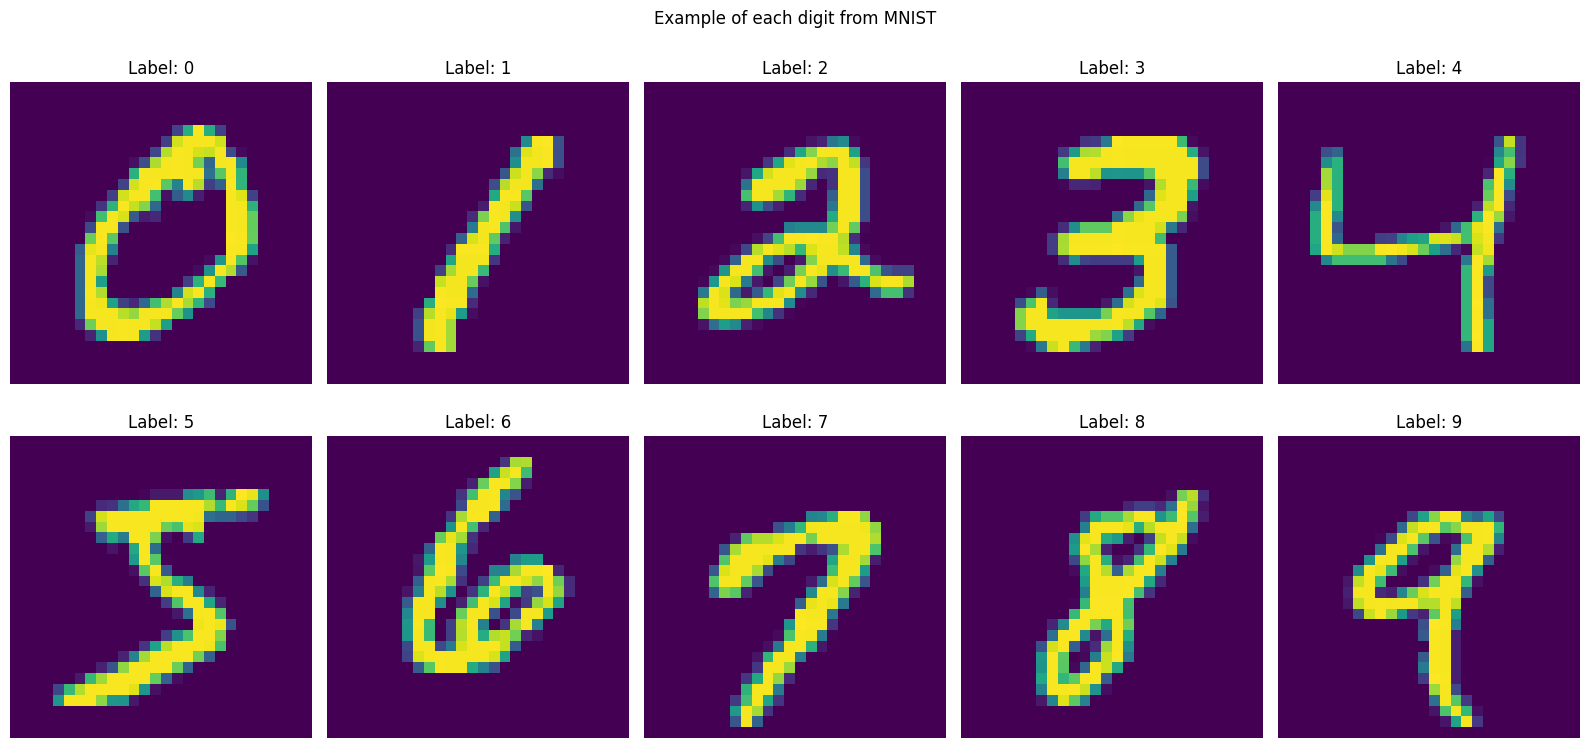

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))

for digit in range(10):
    idx = np.where(y == str(digit))[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X[idx].reshape(28, 28))
    ax.set_title(f'Label: {digit}')
    ax.axis('off')

plt.suptitle('Example of each digit from MNIST')
plt.tight_layout()
plt.show()

### 1.3 Splitting the Dataset

I split the data into 70% training, 15% validation, and 15% test sets. First I split the dataset to 70% for training and 30% for further split. Then I split the 30% set to 2 15% validation and test set. The validation set is used during training for early stopping. The test set is only used at the very end for final evaluation.

"stratify" is necessary to ensure that each digit class is proportionally similar across three sets. Without "stratify", randomize could lead to some classes underrepresented, leading to biased evaluation.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print('Training set:  ', X_train.shape)
print('Validation set:', X_val.shape)
print('Test set:      ', X_test.shape)

Training set:   (49000, 784)
Validation set: (10500, 784)
Test set:       (10500, 784)


### 1.3a Class Distribution

I check that each digit class appears almost equally across all three splits. This confirms stratification worked correctly.

In [5]:
def class_distribution(y, name):
    unique, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    print(f'\n{name} ({len(y)} samples)')
    print(f'{"Digit":<10} {"Count":<10} {"Proportion":<10}')
    print('-' * 30)
    for digit, count, prop in zip(unique, counts, proportions):
        print(f'{digit:<10} {count:<10} {prop:.4f}')

class_distribution(y_train, 'Training set')
class_distribution(y_val,   'Validation set')
class_distribution(y_test,  'Test set')


Training set (49000 samples)
Digit      Count      Proportion
------------------------------
0          4832       0.0986
1          5514       0.1125
2          4893       0.0999
3          4999       0.1020
4          4777       0.0975
5          4419       0.0902
6          4813       0.0982
7          5105       0.1042
8          4777       0.0975
9          4871       0.0994

Validation set (10500 samples)
Digit      Count      Proportion
------------------------------
0          1036       0.0987
1          1182       0.1126
2          1048       0.0998
3          1071       0.1020
4          1023       0.0974
5          947        0.0902
6          1031       0.0982
7          1094       0.1042
8          1024       0.0975
9          1044       0.0994

Test set (10500 samples)
Digit      Count      Proportion
------------------------------
0          1035       0.0986
1          1181       0.1125
2          1049       0.0999
3          1071       0.1020
4          1024       0.

### 1.4 Implementing Softmax Regression with Gradient Descent

Before training I apply two preprocessing steps.

First, I normalised the pixel from 0-255 to 0-1. This prevents large scores which would cause numerical overflow in the exponential function during softmax computation, and helps gradient descent converge faster.

Second, labels are converted to one-hot vectors. The gradient formula requires y_k to be the true probability for class k, which is 1 for the correct class and 0 for all others. This is exactly what a one-hot vector represents.

In [6]:
X_train_norm = X_train / 255.0
X_val_norm   = X_val   / 255.0
X_test_norm  = X_test  / 255.0

def one_hot(y, num_classes=10):
    print(y.shape)
    y_int = y.astype(int) #convert y value to integer
    matrix = np.zeros((len(y), num_classes))
    matrix[np.arange(len(y)), y_int] = 1
    return matrix

Y_train = one_hot(y_train)
Y_val   = one_hot(y_val)
Y_test  = one_hot(y_test)

print('Y_train shape:', Y_train.shape)
print('Example one-hot row:', Y_train[0])

(49000,)
(10500,)
(10500,)
Y_train shape: (49000, 10)
Example one-hot row: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
def softmax(scores):
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    row_exp_sums = np.sum(exp_scores, axis=1, keepdims=True)
    return exp_scores / row_exp_sums

def cross_entropy_loss(probs, Y):
    small_value = 1e-10 #prevent correct_probs = 0 => log(0) = INFINITY
    m = len(Y)
    correct_probs = probs[np.arange(m), Y.argmax(axis=1)]
    return -np.mean(np.log(correct_probs + small_value))

def compute_gradient(X, probs, Y):
    m = len(Y)
    error = probs - Y
    return (X.T @ error) / m

The training loop performs gradient descent. Each iteration computes scores, applies softmax to get probabilities, computes the loss, computes the gradient, and updates the theta (weights).

Early stopping monitors the validation loss. If it does not improve or the improvement is insignificant for a number of consecutive epochs equal to the patience parameter, training stops and the best weights are returned.

In [8]:
def train_softmax(X_train, Y_train, X_val, Y_val,
                  learning_rate=0.1, max_epochs=1000, patience=20, min_delta=1e-4):

    m, n = X_train.shape
    num_classes = Y_train.shape[1]

    theta = np.zeros((n, num_classes)) #weights

    train_losses = []
    val_losses = []

    best_val_loss = np.inf #assign INFINITY value for initial best val loss
    best_theta = theta.copy() #save best weights
    patience_count = 0

    for epoch in range(max_epochs):

        scores = X_train @ theta
        probs  = softmax(scores)
        train_loss = cross_entropy_loss(probs, Y_train)

        val_scores = X_val @ theta
        val_probs = softmax(val_scores)
        val_loss = cross_entropy_loss(val_probs, Y_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        gradient = compute_gradient(X_train,probs,Y_train)
        theta = theta - learning_rate * gradient

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_theta = theta.copy()
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

        if epoch % 50 == 0:
            print(f'Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    return best_theta, train_losses, val_losses

theta, train_losses, val_losses = train_softmax(
    X_train_norm, Y_train, X_val_norm, Y_val, learning_rate=0.2, max_epochs=1000, patience=10, min_delta=1e-4
)

Epoch 0 | Train Loss: 2.3026 | Val Loss: 2.3026
Epoch 50 | Train Loss: 0.6040 | Val Loss: 0.6142
Epoch 100 | Train Loss: 0.4863 | Val Loss: 0.4980
Epoch 150 | Train Loss: 0.4380 | Val Loss: 0.4508
Epoch 200 | Train Loss: 0.4102 | Val Loss: 0.4240
Epoch 250 | Train Loss: 0.3916 | Val Loss: 0.4062
Epoch 300 | Train Loss: 0.3781 | Val Loss: 0.3935
Epoch 350 | Train Loss: 0.3676 | Val Loss: 0.3837
Epoch 400 | Train Loss: 0.3592 | Val Loss: 0.3760
Epoch 450 | Train Loss: 0.3523 | Val Loss: 0.3697
Epoch 500 | Train Loss: 0.3465 | Val Loss: 0.3645
Epoch 550 | Train Loss: 0.3414 | Val Loss: 0.3600
Epoch 600 | Train Loss: 0.3370 | Val Loss: 0.3561
Epoch 650 | Train Loss: 0.3332 | Val Loss: 0.3527
Epoch 700 | Train Loss: 0.3297 | Val Loss: 0.3498
Epoch 750 | Train Loss: 0.3266 | Val Loss: 0.3471
Epoch 800 | Train Loss: 0.3238 | Val Loss: 0.3447
Epoch 850 | Train Loss: 0.3212 | Val Loss: 0.3426
Epoch 900 | Train Loss: 0.3189 | Val Loss: 0.3406
Epoch 950 | Train Loss: 0.3167 | Val Loss: 0.3389


### 1.4a Training and Validation Loss Plot

I plot how the training and validation loss change over epochs.

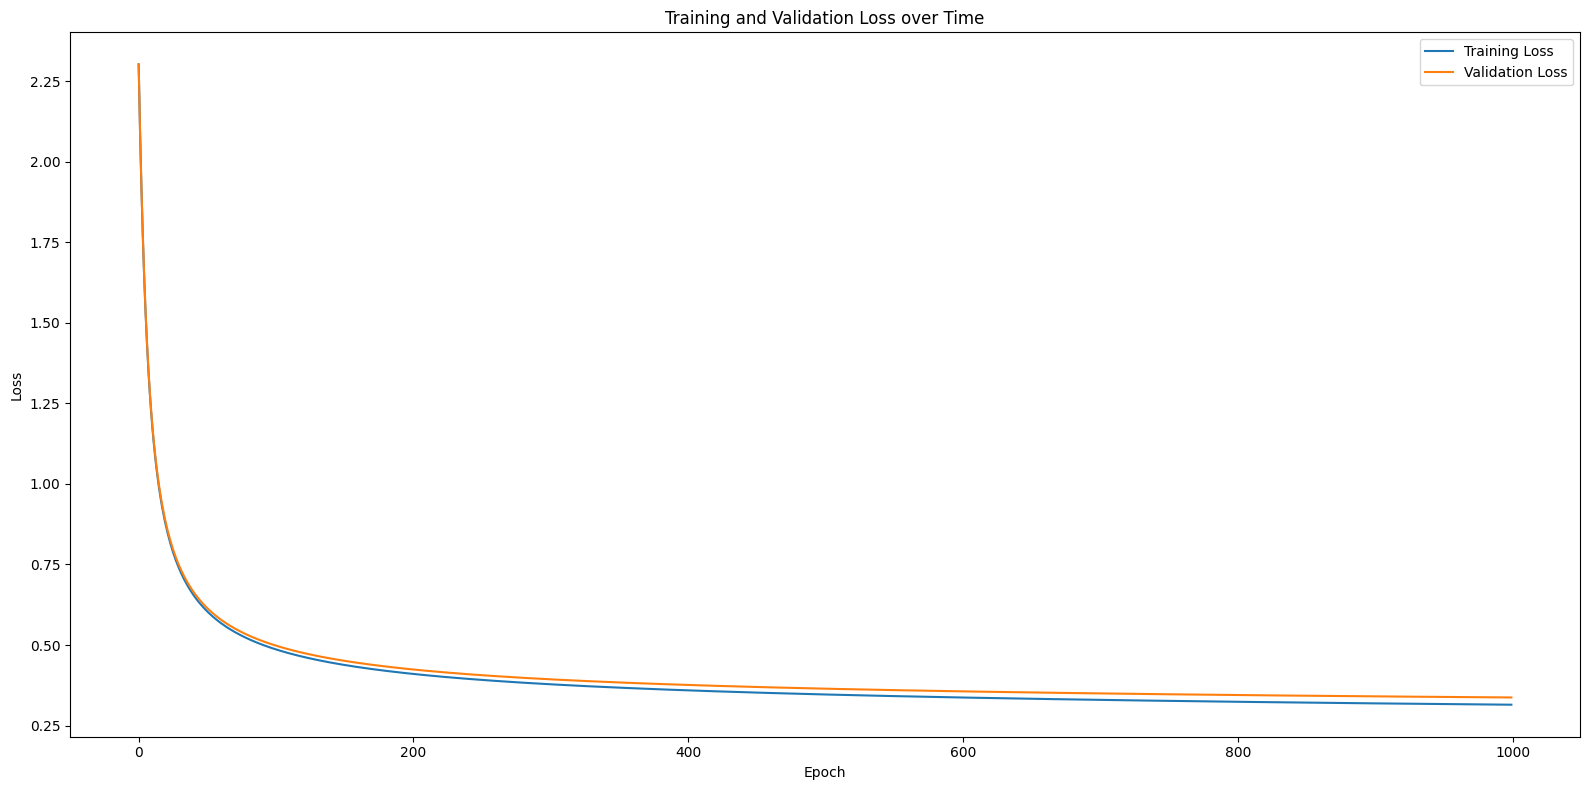

In [9]:
plt.figure(figsize=(16, 8))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 1.4b Observations

Both the training and validation loss decrease steadily over epochs, which is expected behaviour for gradient descent on a well-behaved convex problem. The validation loss closely tracks the training loss, suggesting the model is not significantly overfitting. Early stopping is not triggers in this case because it is still slightly decreasing in the later epochs. To prevent the model from continuing to train on negligible improvements, I can optionally increase the min_delta parameter.

### 1.5 Comparison with scikit-learn LogisticRegression

I fit a scikit-learn LogisticRegression model with no regularisation and compare it against my custom implementation. LogisticRegression in scikit-learn with multi_class='multinomial' is equivalent to softmax regression.

In [10]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression(
    multi_class='multinomial',
    C=1e9,
    max_iter=1000,
    random_state=42
)
sklearn_model.fit(X_train_norm, y_train)
print('sklearn model fitted')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


sklearn model fitted


### 1.5a Display Confusion Matrix for each model
A confusion matrix shows how often the model predicts each class. The diagonal shows correct predictions. Off-diagonal entries show which classes are commonly confused with each other.

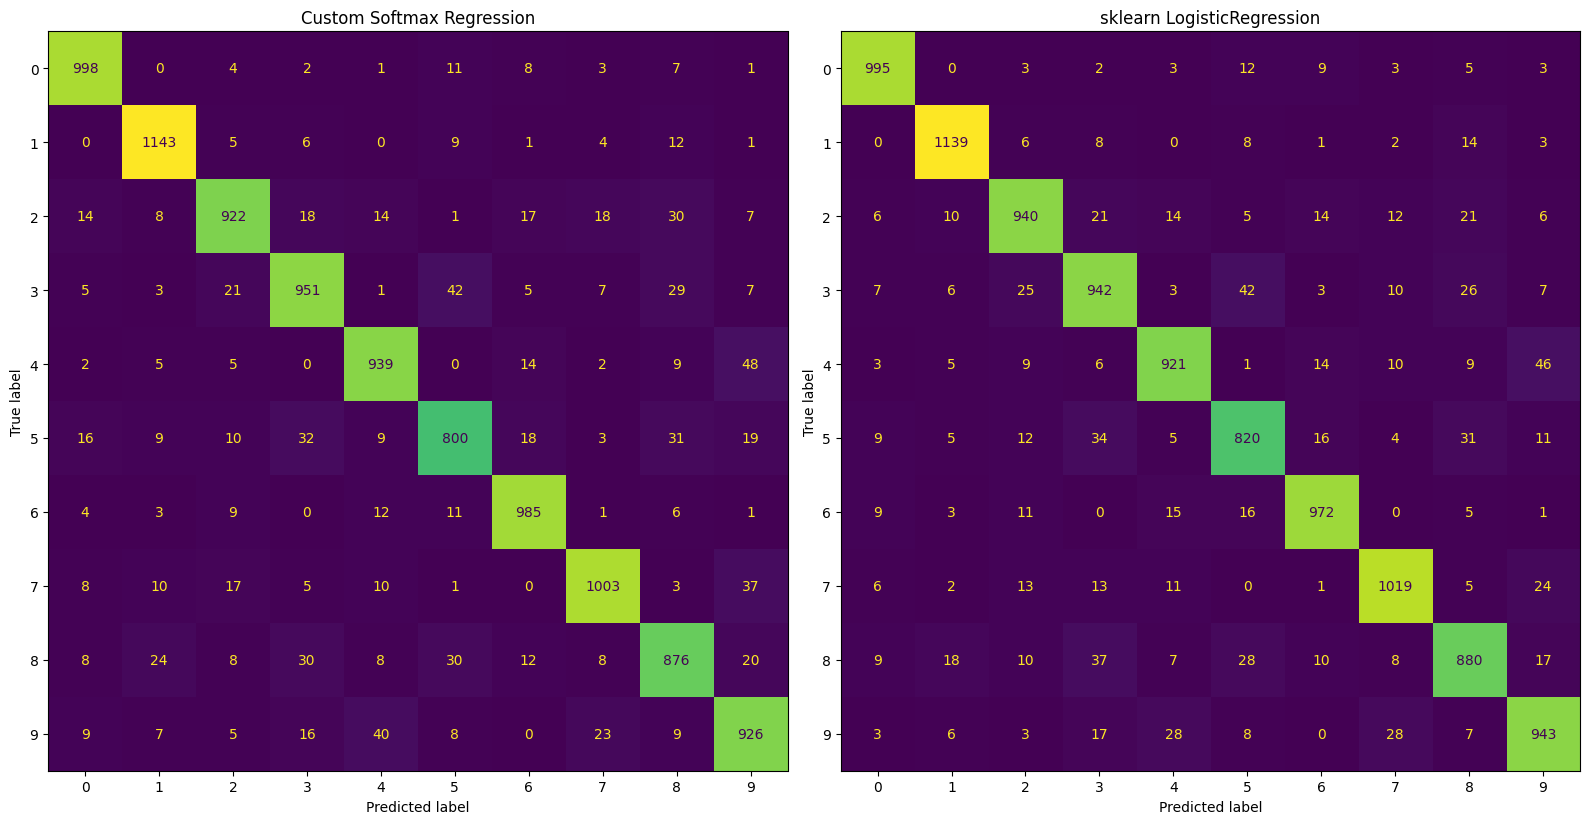

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def predict(X, theta):
    scores = X @ theta
    probs  = softmax(scores)
    return np.argmax(probs, axis=1)

custom_preds  = predict(X_test_norm, theta)
sklearn_preds = sklearn_model.predict(X_test_norm).astype(int)
y_test_int    = y_test.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

cm_custom  = confusion_matrix(y_test_int, custom_preds)
cm_sklearn = confusion_matrix(y_test_int, sklearn_preds)

ConfusionMatrixDisplay(cm_custom,  display_labels=range(10)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Custom Softmax Regression')

ConfusionMatrixDisplay(cm_sklearn, display_labels=range(10)).plot(ax=axes[1], colorbar=False)
axes[1].set_title('sklearn LogisticRegression')

plt.tight_layout()
plt.show()

### 1.5b Evaluation Metrics

Below are report of accuracy, precision, recall and F1-score for both models. These metrics give a complete picture of model performance across all classes.

In [12]:
from sklearn.metrics import classification_report, accuracy_score

print('Custom Softmax Regression')
print(f'Accuracy: {accuracy_score(y_test_int, custom_preds):.4f}')
print(classification_report(y_test_int, custom_preds))

print('sklearn LogisticRegression')
print(f'Accuracy: {accuracy_score(y_test_int, sklearn_preds):.4f}')
print(classification_report(y_test_int, sklearn_preds))

Custom Softmax Regression
Accuracy: 0.9089
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1035
           1       0.94      0.97      0.96      1181
           2       0.92      0.88      0.90      1049
           3       0.90      0.89      0.89      1071
           4       0.91      0.92      0.91      1024
           5       0.88      0.84      0.86       947
           6       0.93      0.95      0.94      1032
           7       0.94      0.92      0.93      1094
           8       0.87      0.86      0.86      1024
           9       0.87      0.89      0.88      1043

    accuracy                           0.91     10500
   macro avg       0.91      0.91      0.91     10500
weighted avg       0.91      0.91      0.91     10500

sklearn LogisticRegression
Accuracy: 0.9115
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1035
           1       0.95      0.96      0.96  

### 1.5c Comments on Results

Both models achieve similar accuracy, which is expected since they are fundamentally the same model. The scikit-learn implementation may perform slightly better because it uses a more sophisticated optimiser (L-BFGS) compared to my basic gradient descent. Both models tend to confuse visually similar digits such as 4 and 9, or 3 and 5, which is expected given the visual similarity between these pairs.

### 1.6 Comparision on models

My custom softmax regression implementation achieves comparable performance to the scikit-learn LogisticRegression model. The small difference in accuracy is attributed to the difference in optimisation algorithms. My implementation uses basic gradient descent which converges more slowly, while scikit-learn uses L-BFGS as its default which is a second-order optimiser that converges much faster and to a more precise solution.

## Part 2: Support Vector Machine Regression

### 2.1 Polynomial Dataset Generator

I write a function to generate random polynomial datasets of degree n. The function samples x uniformly from [-3, 3], generates random coefficients, computes y as a polynomial in x, and adds Gaussian noise.

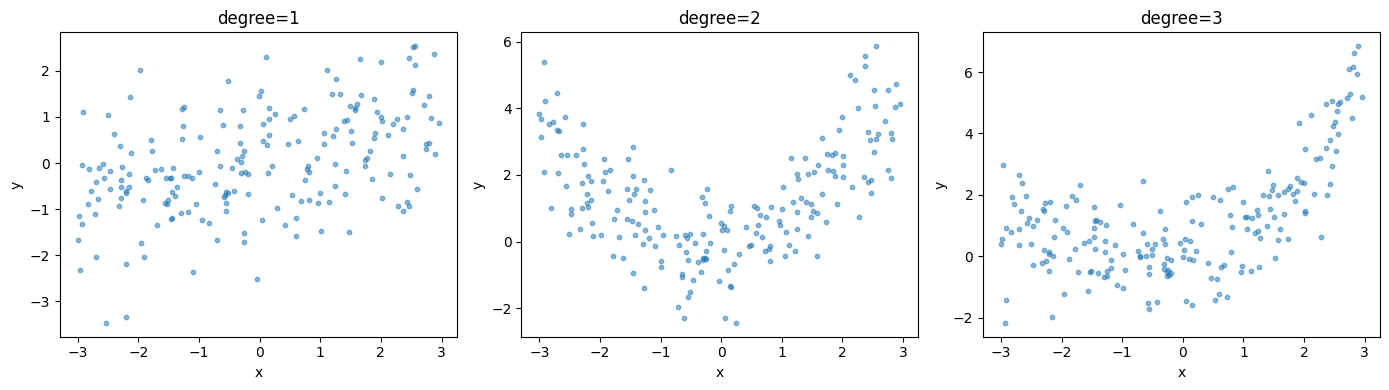

In [13]:
def generate_polynomial_dataset(degree, n_samples, random_state=40):
    rng = np.random.RandomState(random_state)
    x = rng.uniform(-3, 3, n_samples)
    coefficients = rng.uniform(0, 1, degree + 1)
    y = np.zeros(n_samples)
    for k in range(degree + 1):
        y += coefficients[k] * (x ** k)
    y += rng.normal(0, 1, n_samples) #noise
    # print(x.shape,str(n_samples))
    return x.reshape(n_samples, 1), y

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, degree in enumerate([1, 2, 3]):
    x_demo, y_demo = generate_polynomial_dataset(degree, 200)
    axes[i].scatter(x_demo, y_demo, alpha=0.5, s=10)
    axes[i].set_title(f'degree={degree}')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
plt.tight_layout()
plt.show()

### 2.2 Generate Three Datasets

I generate linear, quadratic and cubic datasets with 1000 samples each and split each into training and test sets with test size=0.2.

In [14]:
X_lin, y_lin = generate_polynomial_dataset(degree=1, n_samples=1000, random_state=0)
X_quad, y_quad = generate_polynomial_dataset(degree=2, n_samples=1000, random_state=1)
X_cub, y_cub = generate_polynomial_dataset(degree=3, n_samples=1000, random_state=2)

X_lin_train,  X_lin_test,  y_lin_train,  y_lin_test  = train_test_split(X_lin,  y_lin,  test_size=0.2, random_state=42)
X_quad_train, X_quad_test, y_quad_train, y_quad_test = train_test_split(X_quad, y_quad, test_size=0.2, random_state=42)
X_cub_train,  X_cub_test,  y_cub_train,  y_cub_test  = train_test_split(X_cub,  y_cub,  test_size=0.2, random_state=42)

print('Linear train/test:', X_lin_train.shape, X_lin_test.shape)
print('Quadratic train/test:', X_quad_train.shape, X_quad_test.shape)
print('Cubic train/test:', X_cub_train.shape, X_cub_test.shape)

Linear train/test: (800, 1) (200, 1)
Quadratic train/test: (800, 1) (200, 1)
Cubic train/test: (800, 1) (200, 1)


### 2.3 Fitting SVR with Different Kernels
I fit SVR models with linear, polynomial and RBF kernels to each of the three datasets. The linear kernel fits a straight line. The poly kernel fits polynomial curves. The RBF kernel is a very flexible smoother that can fit complex non-linear patterns.

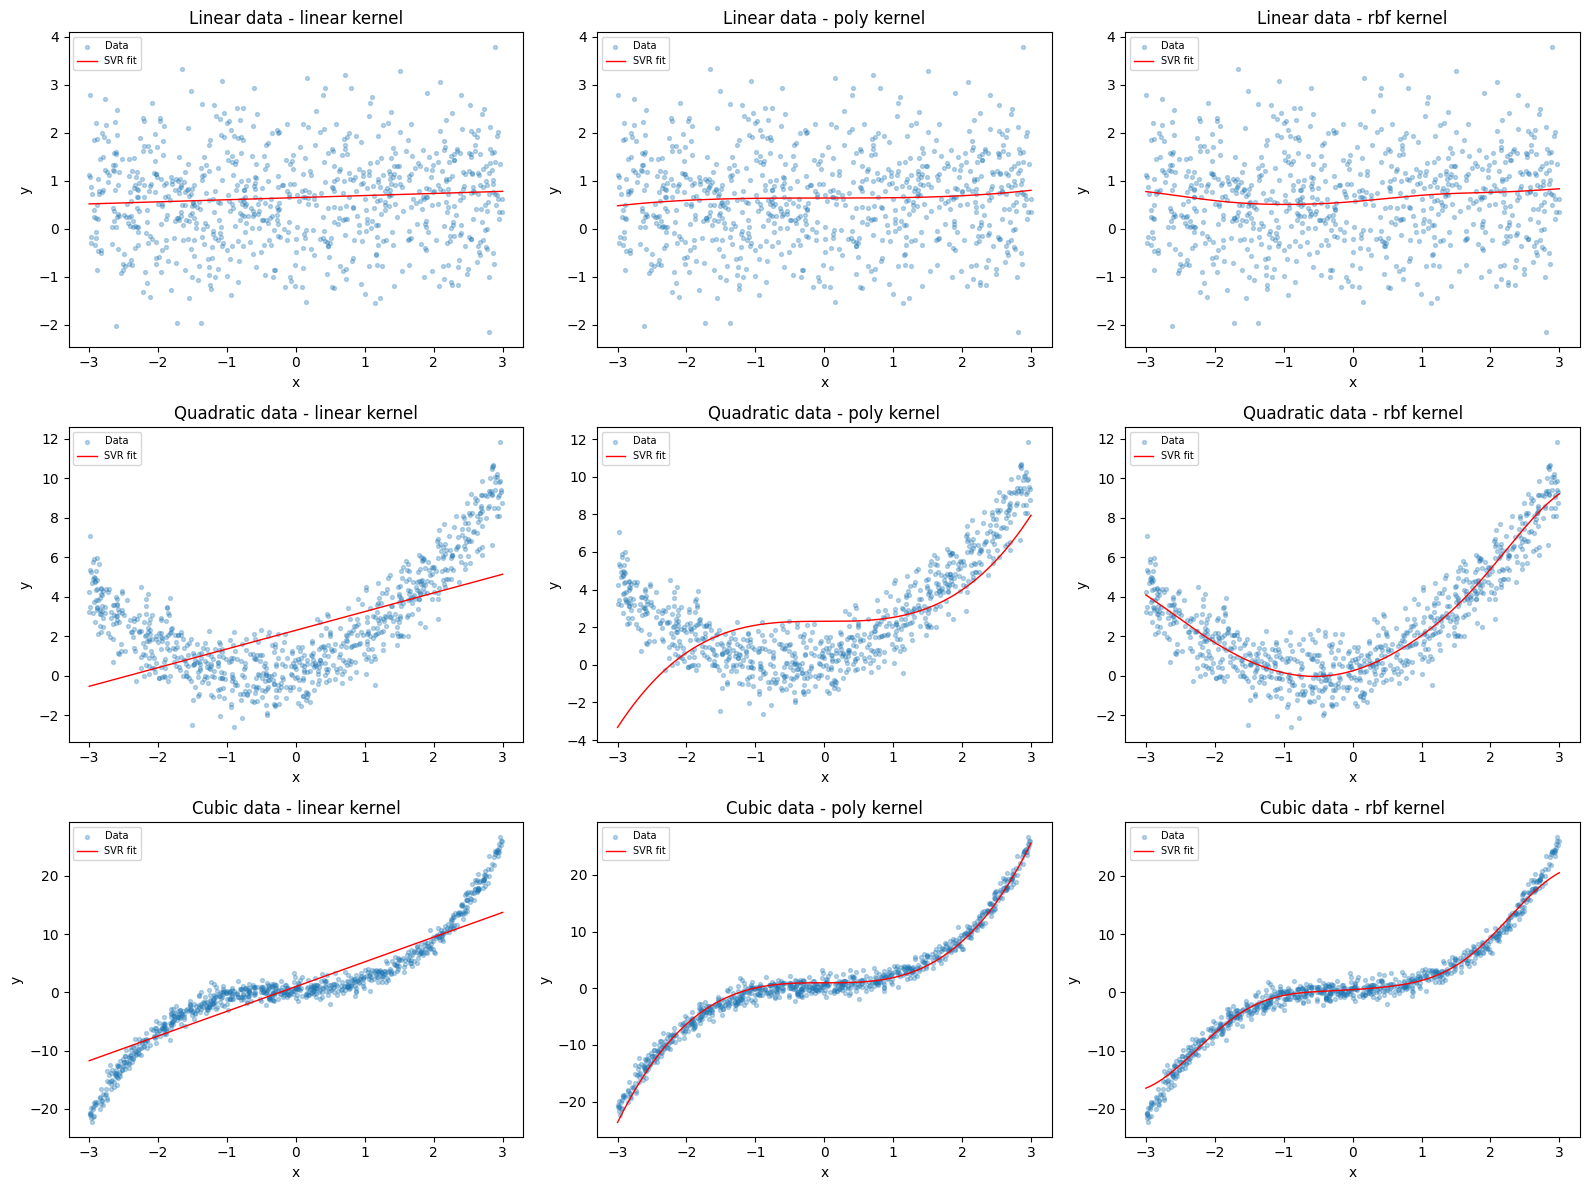

In [15]:
from sklearn.svm import SVR

datasets = [
    ('Linear',    X_lin_train,  y_lin_train,  X_lin_test),
    ('Quadratic', X_quad_train, y_quad_train, X_quad_test),
    ('Cubic',     X_cub_train,  y_cub_train,  X_cub_test)
]

kernels = ['linear', 'poly', 'rbf']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

for row, (name, X_tr, y_tr, X_te) in enumerate(datasets):
    for col, kernel in enumerate(kernels):
        model = SVR(kernel=kernel)
        model.fit(X_tr, y_tr)
        y_plot = model.predict(x_plot)

        ax = axes[row, col]
        ax.scatter(X_tr, y_tr, alpha=0.3, s=8, label='Data')
        ax.plot(x_plot, y_plot, color='red', linewidth=1, label='SVR fit')
        ax.set_title(f'{name} data - {kernel} kernel')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 2.3b Comments on Results

With the linear data, none of the three kernels really managed to fit the data well since the noise was too strong relative to the weak linear trend, so the predictions came out irrelevant. For the quadratic data, the linear kernel couldn't pick up the curved shape at all, but both the polynomial and RBF kernels did a much better job, with RBF getting closest to the U-shaped curve. The cubic data was where the polynomial kernel advance, tracking the S-shaped curve closely, and RBF handled it reasonably well too, though the linear kernel could only approximate the overall direction without capturing what happens at the ends. Finally, RBF turned out to be the most flexible kernel across all three datasets, while the polynomial kernel works best when the data actually follows a polynomial pattern.

### 2.4 Grid Search with Cross Validation on Cubic Dataset


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel':  ['poly', 'rbf'],
    'C':       [1, 10],
    'epsilon': [0.1, 0.5]
}

grid_search = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1
)

grid_search.fit(X_cub_train, y_cub_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV MSE:', -grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}
Best CV MSE: 1.0234032161805133


### 2.4a Hyperparameter Choices

I choose kernel (poly vs rbf) as it fundamentally changes how the model fits curves. C controls the trade-off between fitting the training data and allowing errors, a higher C means the model tries harder to fit training points. Epsilon controls the width of the margin within which no penalty is given, a higher epsilon allows more error tolerance. With 3 hyperparameters and 2 values each 2^3 = 8 combinations, and with 5-fold CV that means it fits 8 x 5 = 40 models in total.

###2.4b Optimal hyperparameter combination
The optimal combination after running GridSearchCV is C = 10, epsilon = 0.5, kernel = rbf with Mean Square Error equal 1.0234

In [17]:
print('Grid search results:')
results = grid_search.cv_results_
for mean, params in zip(results['mean_test_score'], results['params']):
    print(f'MSE: {-mean:.4f} | params: {params}')

print('\nOptimal combination:')
print(grid_search.best_params_)

Grid search results:
MSE: 1.3954 | params: {'C': 1, 'epsilon': 0.1, 'kernel': 'poly'}
MSE: 2.3547 | params: {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}
MSE: 1.3887 | params: {'C': 1, 'epsilon': 0.5, 'kernel': 'poly'}
MSE: 2.3639 | params: {'C': 1, 'epsilon': 0.5, 'kernel': 'rbf'}
MSE: 1.3959 | params: {'C': 10, 'epsilon': 0.1, 'kernel': 'poly'}
MSE: 1.0278 | params: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
MSE: 1.3898 | params: {'C': 10, 'epsilon': 0.5, 'kernel': 'poly'}
MSE: 1.0234 | params: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}

Optimal combination:
{'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}


### 2.5 Evaluating the Best Model on the Test Set

The best SVR model did a pretty solid job on the cubic test set. With an R2 score of 0.9890, it's capturing nearly all of the variance in the data, and the MSE of 1.0277 is low enough to show that predictions are really close to the actual values.

From the plot, the red line follows the S-curve nicely and stays tight with the scatter of blue test points. There's a bit of spread around the line, but that's really just noise in the data rather than anything the model is getting wrong.

Test MSE: 1.0277
Test R2:  0.9890


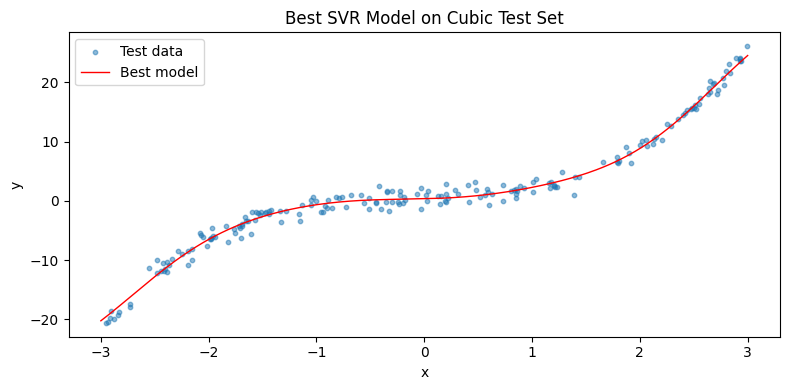

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_cub_test)

mse = mean_squared_error(y_cub_test, y_pred)
r2  = r2_score(y_cub_test, y_pred)

print(f'Test MSE: {mse:.4f}')
print(f'Test R2:  {r2:.4f}')

plt.figure(figsize=(8, 4))
plt.scatter(X_cub_test, y_cub_test, alpha=0.5, s=10, label='Test data')
plt.plot(x_plot, best_model.predict(x_plot), color='red', linewidth=1, label='Best model')
plt.title(f'Best SVR Model on Cubic Test Set')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()